# DESAFIO 05 - Diagnóstico de Câncer de Mama

**Disciplina:** A.I - Machine Learning  

Profª. Ma. Nathalia A. Lima

Discentes:

| **Discentes** | **RA** |
:------------------------: | :------------------------: |
| Rayssa Gomides Marconato |2001130  |
| Samara Adorno | 2001639        |


## INFORMAÇÕES DO DESAFIO
- **Grupo:** 5
- **Tipo:** Classificação Binária
- **Domínio:** Saúde
- **Dataset Kaggle:** uciml/breast-cancer-wisconsin-data

## OBJETIVO
Classificar tumores de mama como malignos ou benignos baseado em características
celulares.

## Contexto do Problema
O diagnóstico precoce e preciso é crucial para tratamento. Características de células obtidas
por biópsia podem indicar malignidade.

## Sumário

- DESAFIO 05 - Diagnóstico de Câncer de Mama
- 1. Importação dos módulos
  - Explicação: Importação dos módulos
- 2. Leitura e verificação dos dados
  - Explicação: Leitura e verificação dos dados
- 3. Exploração dos Dados (EDA)
  - Distribuição das classes
  - Histogramas
  - Boxplots (detectar outliers)
  - Correlação
  - Pairplot
  - Explicação: Exploração dos Dados (EDA)
- 4. Pré-processamento
  - Explicação: Pré-processamento dos Dados
  - Converter a variável alvo (diagnosis)
  - Separar os dados em características (X) e alvo (y)
  - Dividir os dados para treino e teste (com estratificação)
  - Normalização (Escalonamento dos Dados)
  - PCA - Análise de Componentes Principais
- 5. Comparação de Modelos + Métricas
  - Explicação: Comparação de Modelos e Métricas de Avaliação
  - Matrizes de Confusão
  - Curva ROC (Receiver Operating Characteristic)
  - Resultados Finais Comparados
- 6. Validação Cruzada e Otimização de Hiperparâmetros
  - Explicação: Validação Cruzada e Otimização de Hiperparâmetros
  - Otimização de Hiperparâmetros (GridSearchCV)
  - Avaliação dos Modelos Otimizados
- 7. Análise de Importância de Features (RandomForest)
  - Explicação: Análise de Importância de Features (RandomForest)
- Explicação Detalhada da Matriz de Confusão

In [ ]:
from google.colab import files
files.upload()

Saving data.csv to data.csv


{'data.csv': b'"id","diagnosis","radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean","compactness_mean","concavity_mean","concave points_mean","symmetry_mean","fractal_dimension_mean","radius_se","texture_se","perimeter_se","area_se","smoothness_se","compactness_se","concavity_se","concave points_se","symmetry_se","fractal_dimension_se","radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst","compactness_worst","concavity_worst","concave points_worst","symmetry_worst","fractal_dimension_worst",\r\n842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189\r\n842517,M,20.57,17.77,132.9,1326,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.0186,0.0134,0.01389,0.003532,24.99,23.41,158.8,1956,0.1238,0.1866,0.2416,0.186,0.275,0.08902\r\n84300903,M,1

## 1. Importação dos módulos

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

### Explicação: Importação dos módulos

Neste bloco, as bibliotecas essenciais para a análise de dados e construção de modelos de Machine Learning são importadas:

*   **`pandas` (pd)**: Utilizada para manipulação e análise de dados tabulares (DataFrames).
*   **`numpy` (np)**: Fornece suporte para arrays e matrizes, com funções matemáticas de alto nível.
*   **`matplotlib.pyplot` (plt)**: Biblioteca para criação de gráficos estáticos, interativos e animados em Python.
*   **`seaborn` (sns)**: Baseada em `matplotlib`, oferece uma interface de alto nível para a criação de gráficos estatísticos atraentes e informativos.
*   **`sklearn.model_selection`**: Contém ferramentas para divisão de dados (ex: `train_test_split`), validação cruzada (`StratifiedKFold`) e otimização de hiperparâmetros (`GridSearchCV`).
*   **`sklearn.preprocessing.StandardScaler`**: Usado para normalizar as características do dataset, escalando-as para que tenham média zero e variância unitária.
*   **`sklearn.decomposition.PCA`**: Implementa a Análise de Componentes Principais para redução de dimensionalidade.
*   **`sklearn.svm.SVC`**: Implementa o algoritmo Support Vector Classifier para classificação.
*   **`sklearn.ensemble.RandomForestClassifier`**: Implementa o algoritmo de Floresta Aleatória para classificação.
*   **`sklearn.naive_bayes.GaussianNB`**: Implementa o algoritmo Gaussian Naive Bayes para classificação.
*   **`sklearn.metrics`**: Contém várias funções para avaliar o desempenho dos modelos de classificação, como acurácia, precisão, recall, F1-score, AUC, matriz de confusão, etc.

## 2. Leitura e verificação dos dados

In [ ]:
df = pd.read_csv('/content/data.csv')

In [ ]:
df.head(1)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN


In [ ]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.shape

(569, 33)

In [ ]:
# Valores nulos
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
# Estatísticas
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


### Explicação: Leitura e verificação dos dados

Nesta seção, o conjunto de dados é carregado e uma inspeção inicial é realizada para entender sua estrutura, identificar valores ausentes e obter estatísticas descritivas.

*   **`df = pd.read_csv('/content/data.csv')`**: Carrega o arquivo CSV nomeado `data.csv` (que foi previamente enviado para o ambiente) em um DataFrame do pandas chamado `df`.
*   **`df.head(1)`**: Exibe a primeira linha do DataFrame, permitindo uma visualização rápida das colunas e dos tipos de dados. A saída mostra as 33 colunas, incluindo 'id', 'diagnosis' e as várias características relacionadas ao tumor, além de uma coluna 'Unnamed: 32' com valores `NaN`.
*   **`df.info()`**: Fornece um resumo conciso do DataFrame, incluindo o número de entradas, o número de colunas, o tipo de dado de cada coluna (Dtype), e a contagem de valores não nulos (`Non-Null Count`). A saída mostra 569 entradas e 33 colunas. É importante notar que a coluna `Unnamed: 32` tem 0 valores não nulos, indicando que está completamente vazia.
*   **`df.shape`**: Retorna uma tupla representando as dimensões do DataFrame (número de linhas, número de colunas). A saída `(569, 33)` confirma que o dataset possui 569 amostras e 33 características.
*   **`df.isnull().sum()`**: Calcula o número de valores nulos (missing values) para cada coluna. A saída confirma que `Unnamed: 32` é a única coluna com 569 valores nulos (ou seja, todos os valores são nulos).
*   **`df.describe()`**: Gera estatísticas descritivas das colunas numéricas do DataFrame, como contagem, média, desvio padrão, mínimo, quartis (25%, 50%, 75%) e máximo. Isso é útil para entender a distribuição e a escala das características.

## 3. Exploração dos Dados (EDA)

### Distribuição das classes

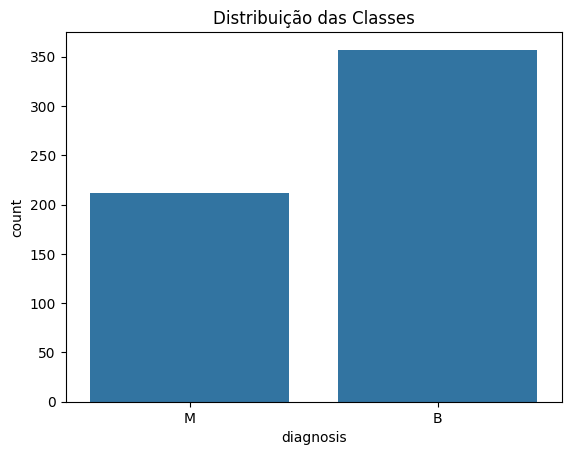

In [ ]:
sns.countplot(x='diagnosis', data=df)
plt.title('Distribuição das Classes')
plt.show()

In [ ]:
# Contagem absoluta
contagem = df['diagnosis'].value_counts()
print("\nDistribuição das Classes (Absoluto):")
print(contagem)

# Contagem em porcentagem
porcentagem = df['diagnosis'].value_counts(normalize=True) * 100
print("\nDistribuição das Classes (Porcentagem):")
print(porcentagem)



Distribuição das Classes (Absoluto):
diagnosis
B    357
M    212
Name: count, dtype: int64

Distribuição das Classes (Porcentagem):
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


### Histogramas

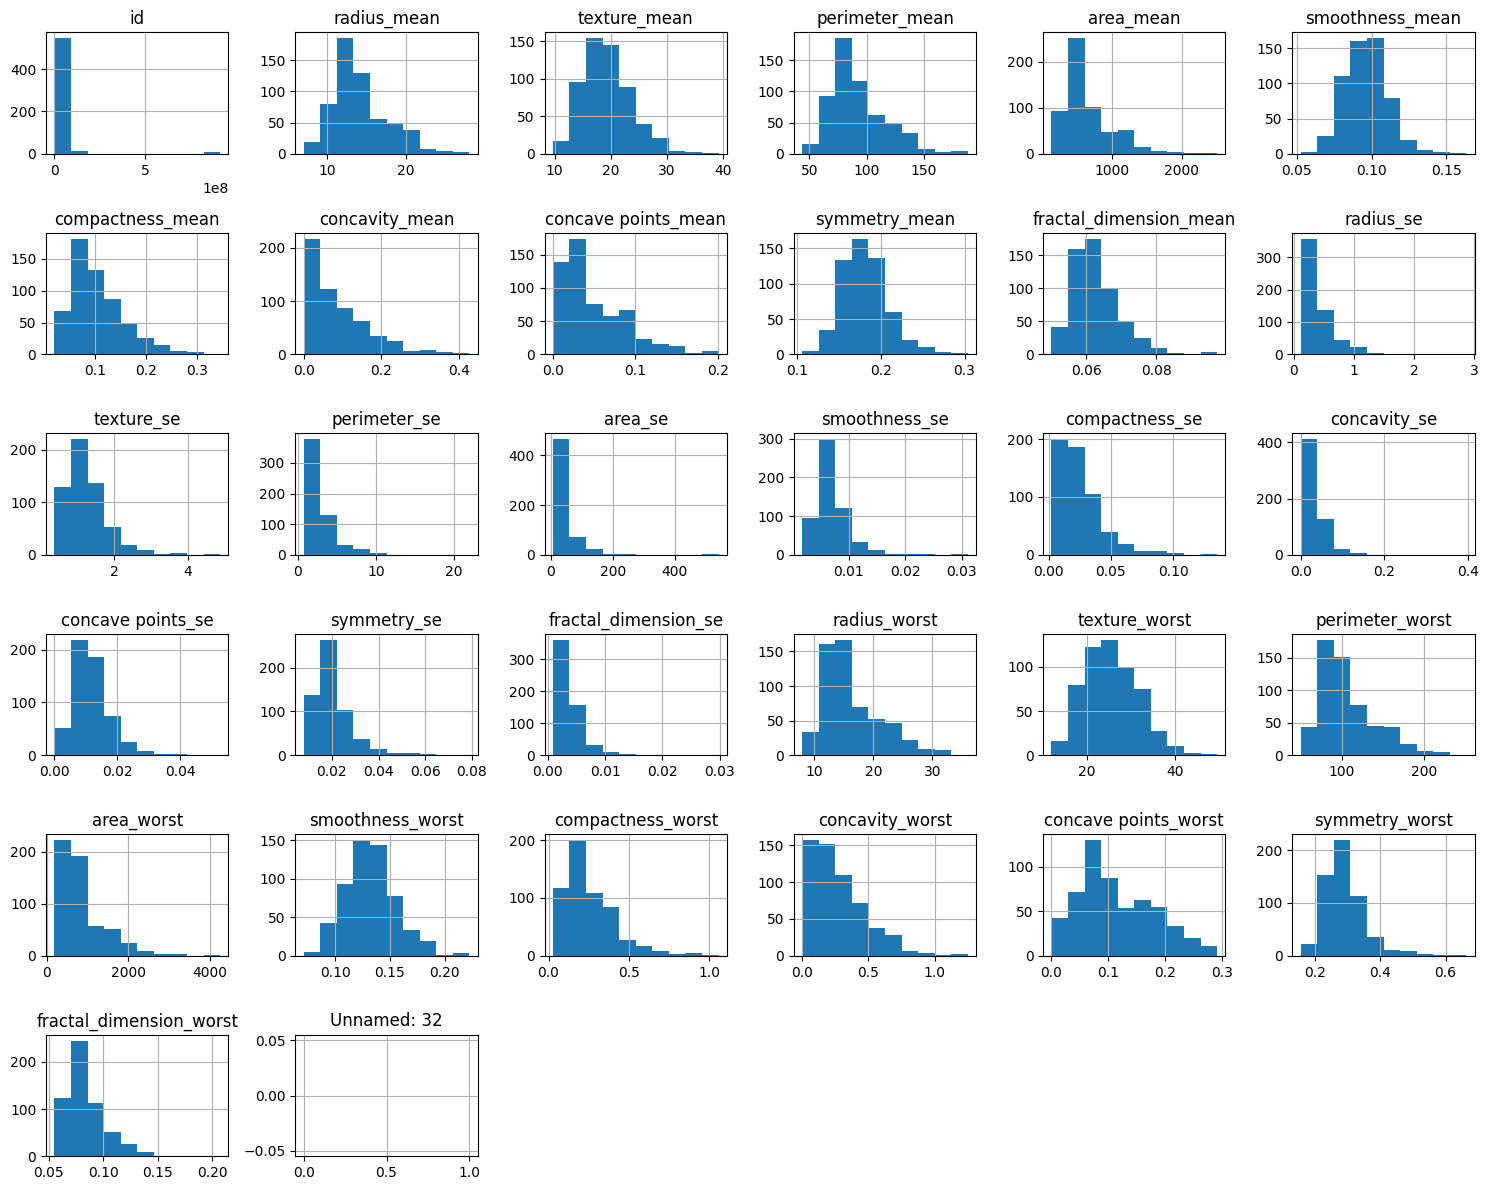

In [ ]:
df.hist(figsize=(15, 12))
plt.tight_layout()
plt.show()

### Boxplots (detectar outliers)

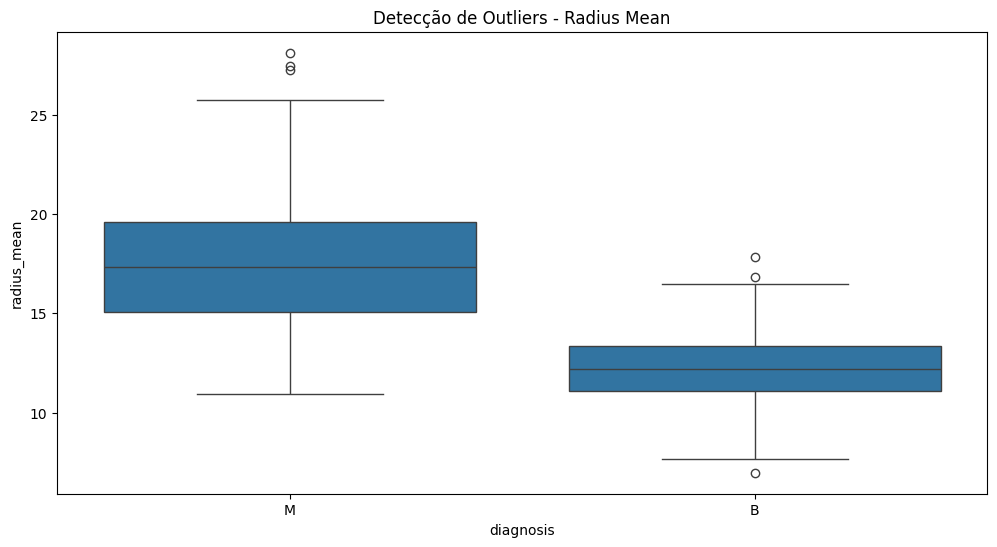

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title('Detecção de Outliers - Radius Mean')
plt.show()

Existem outliers principalmente em tumores malignos
Isso é esperado em dados médicos

### Correlação

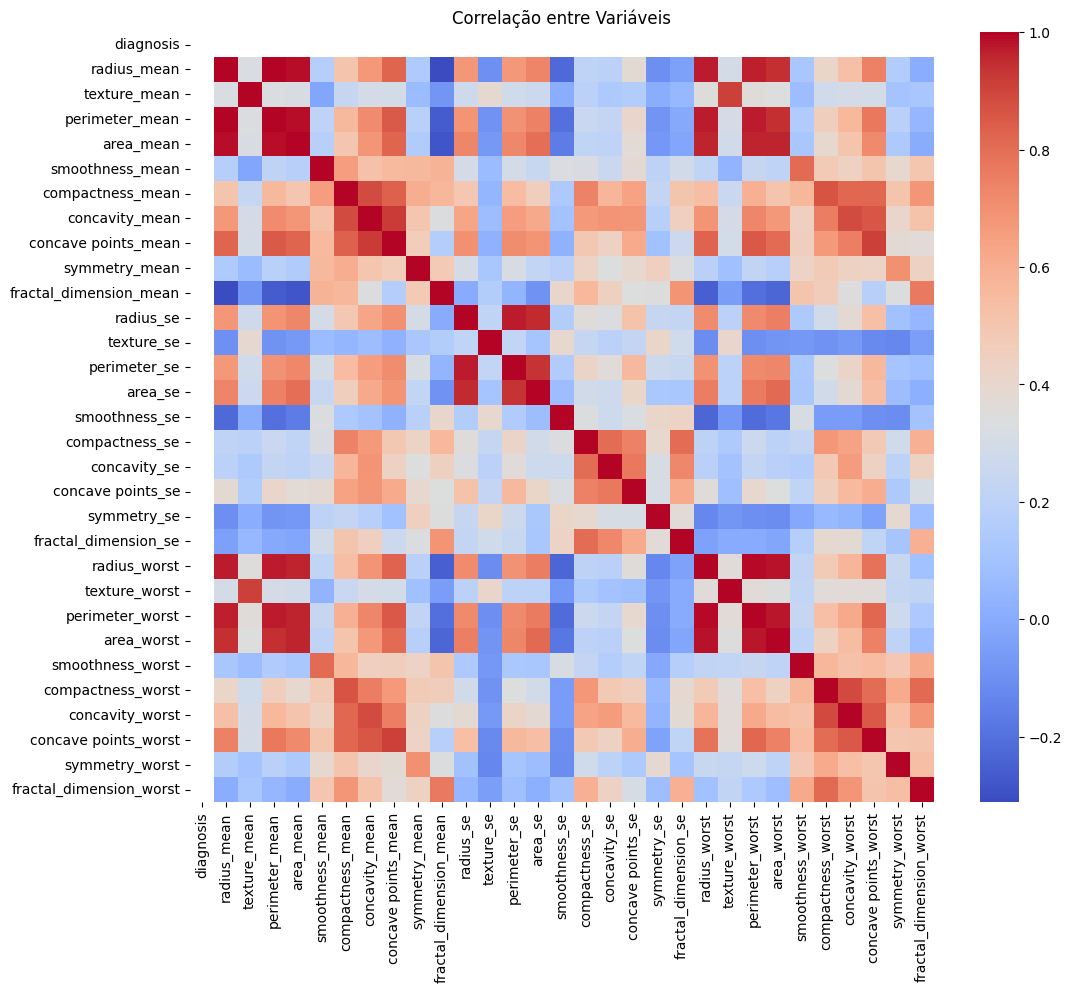

In [ ]:
df_corr = df.copy()

df_corr['diagnosis'] = df_corr['diagnosis'].map({'M': 1, 'B': 0})

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), cmap='coolwarm')
plt.title('Correlação entre Variáveis')
plt.show()

### Pairplot

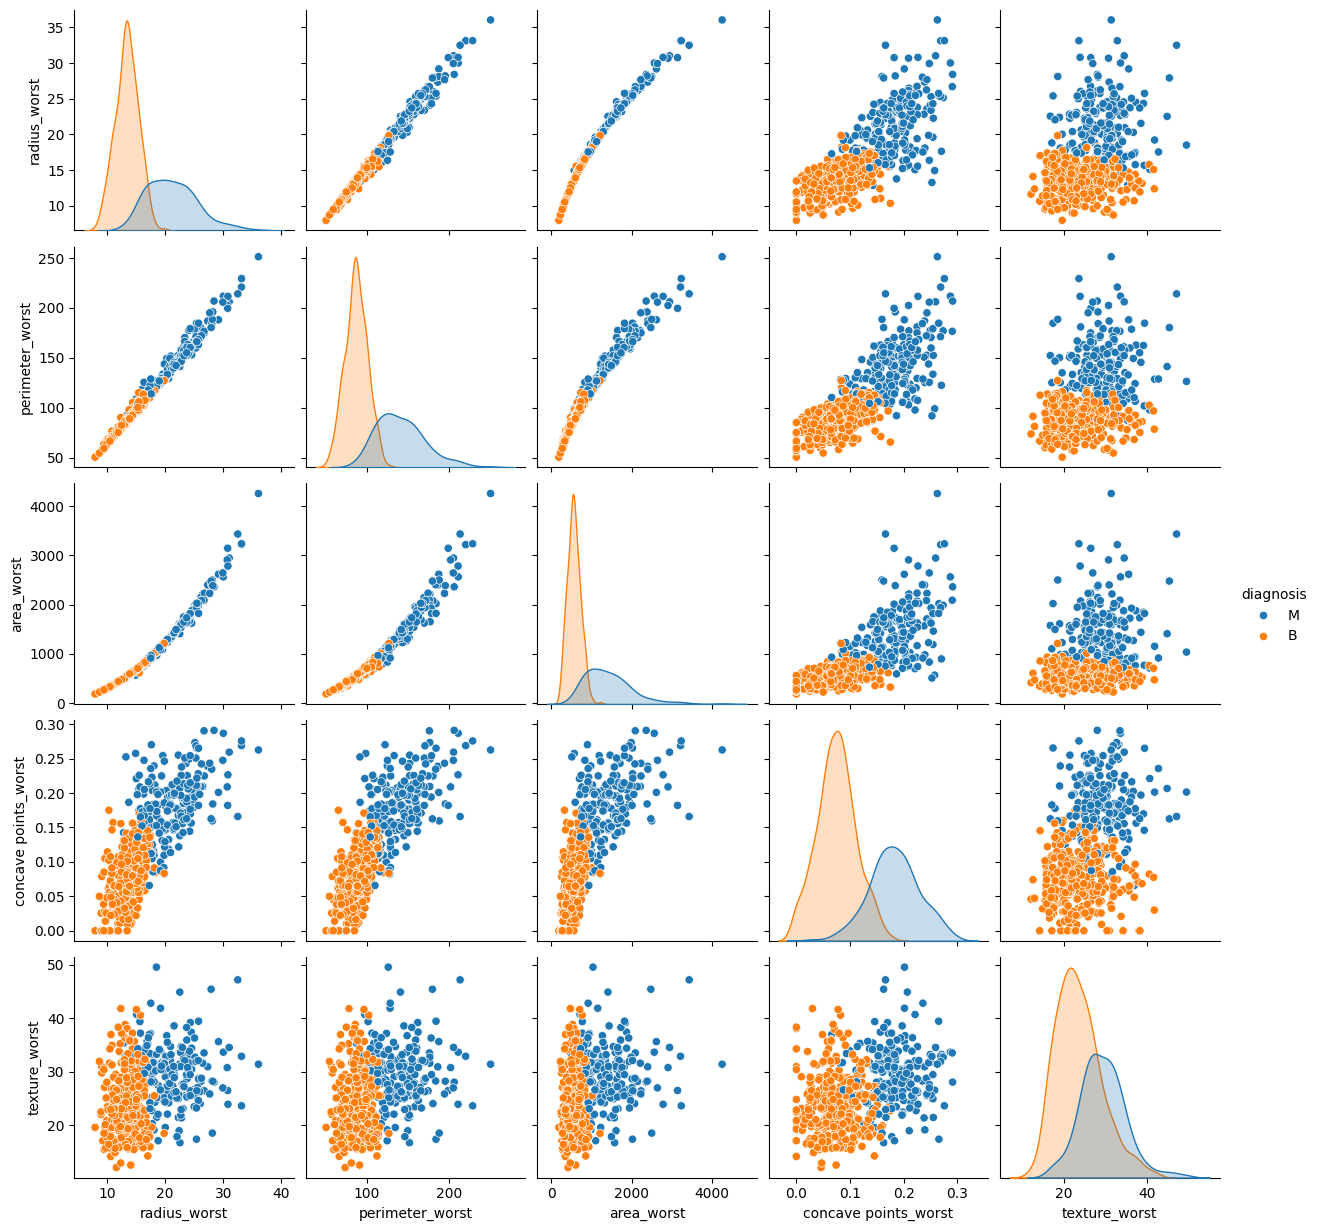

In [ ]:
features = ['radius_worst', 'perimeter_worst', 'area_worst', 'concave points_worst', 'texture_worst']

sns.pairplot(df[features + ['diagnosis']], hue='diagnosis')
plt.show()

### Explicação: Exploração dos Dados (EDA)

Esta seção foca na Análise Exploratória de Dados, utilizando visualizações para entender a distribuição das classes, das características e suas correlações.

#### Distribuição das Classes

*   **`sns.countplot(x='diagnosis', data=df)` e `plt.title('Distribuição das Classes')`**: Cria um gráfico de barras que mostra a contagem de cada categoria na coluna `diagnosis`. A saída visual indica que a classe 'B' (benigno) é mais frequente que a 'M' (maligno).
*   **`df['diagnosis'].value_counts()`**: Mostra a contagem absoluta de cada classe na coluna `diagnosis`. A saída `B    357` e `M    212` confirma o desequilíbrio de classes.
*   **`df['diagnosis'].value_counts(normalize=True) * 100`**: Mostra a porcentagem de cada classe. A saída `B    62.74%` e `M    37.26%` quantifica o desequilíbrio, sendo aproximadamente 63% benignos e 37% malignos.

#### Histogramas

*   **`df.hist(figsize=(15, 12))`**: Gera histogramas para todas as colunas numéricas do DataFrame. Histogramas são úteis para visualizar a distribuição de uma única variável contínua, ajudando a identificar a forma da distribuição (normal, assimétrica), o centro e a dispersão dos dados.

#### Boxplots (detecção de outliers)

*   **`sns.boxplot(x='diagnosis', y='radius_mean', data=df)`**: Cria um boxplot para a característica `radius_mean`, segmentado pela `diagnosis`. Boxplots são excelentes para visualizar a distribuição de dados numéricos e identificar outliers. A saída visual mostra a presença de outliers, especialmente para tumores malignos (`M`), o que é comum e esperado em dados médicos.

#### Correlação

*   **`df_corr = df.copy()` e `df_corr['diagnosis'] = df_corr['diagnosis'].map({'M': 1, 'B': 0})`**: Uma cópia do DataFrame é feita e a coluna `diagnosis` é convertida para valores numéricos (M=1, B=0) para que possa ser incluída no cálculo da correlação.
*   **`sns.heatmap(df_corr.corr(), cmap='coolwarm')`**: Gera um mapa de calor da matriz de correlação entre todas as variáveis numéricas. O mapa de calor visualiza a força e a direção da relação linear entre pares de variáveis. Cores mais quentes (vermelho) indicam correlação positiva forte, e cores mais frias (azul) indicam correlação negativa forte. Isso ajuda a identificar características que são altamente correlacionadas entre si ou com a variável alvo (`diagnosis`).

#### Pairplot

*   **`features = ['radius_worst', ..., 'texture_worst']`**: Seleciona um subconjunto de características para visualização.
*   **`sns.pairplot(df[features + ['diagnosis']], hue='diagnosis')`**: Cria uma matriz de gráficos de dispersão (scatter plots) para todas as combinações de pares de características selecionadas. A cor dos pontos é determinada pela `diagnosis`. Nos gráficos da diagonal, são exibidos histogramas (ou KDEs) para a distribuição de cada característica. O pairplot é útil para visualizar as relações entre múltiplas variáveis e a separabilidade das classes.

## 4. Pré-processamento

In [ ]:
# Remover colunas irrelevantes
df = df.drop(['id', 'Unnamed: 32'], axis=1)

In [ ]:
# Converter variável alvo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
# Separação de variáveis
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [ ]:
# Divisão com estratificação para treino, validação e teste
# Primeiro, divide-se em treino+validação (80%) e teste (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Em seguida, divide-se o conjunto treino+validação em treino (75% de 80% = 60% total)
# e validação (25% de 80% = 20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

In [ ]:
# Normalização
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

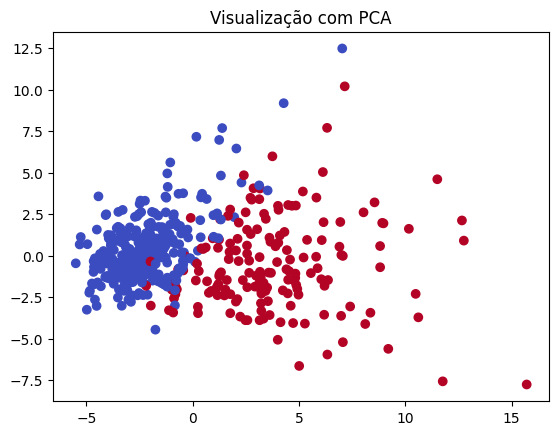

In [ ]:
# PCA - Principal Component Analysis - Análise de Componentes Principais
pca = PCA(n_components=2)
X_pca_train = pca.fit_transform(X_train_scaled)

plt.scatter(X_pca_train[:,0], X_pca_train[:,1], c=y_train, cmap='coolwarm')
plt.title('Visualização com PCA (Dados de Treino)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

## Explicação: Pré-processamento dos Dados

Esta etapa é crucial para preparar os dados antes de treinar os modelos de Machine Learning. É como organizar e limpar os ingredientes antes de cozinhar.

### Remover colunas que não são úteis (`id`, `Unnamed: 32`)

*   **`df = df.drop(['id', 'Unnamed: 32'], axis=1)`**: Aqui, removemos a coluna `'id'`, que é apenas um identificador e não ajuda o modelo a aprender. Também removemos a coluna `'Unnamed: 32'`, que vimos na inspeção inicial que estava completamente vazia (só tinha valores nulos). `axis=1` significa que estamos removendo colunas (não linhas).

### Converter a variável alvo (`diagnosis`)

*   **`df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})`**: A coluna `'diagnosis'` tem valores de texto ('M' para Maligno e 'B' para Benigno). Os modelos de Machine Learning geralmente precisam de números, então convertemos 'M' para `1` e 'B' para `0`. Isso é essencial para que o modelo entenda qual é a saída que ele deve prever.

### Separar os dados em características (X) e alvo (y)

*   **`X = df.drop('diagnosis', axis=1)`**: `X` (as características) são todas as colunas do seu conjunto de dados, exceto a coluna que você quer prever (`'diagnosis'`). `axis=1` indica que 'diagnosis' é uma coluna.
*   **`y = df['diagnosis']`**: `y` (a variável alvo) é a coluna que queremos que o modelo aprenda a prever, que neste caso é o `'diagnosis'` (se o tumor é benigno ou maligno).

### Dividir os dados para treino, validação e teste (com estratificação)

*   **Divisão em Três Partes**: Agora, dividimos nossos dados em três conjuntos para uma avaliação mais robusta:
    *   **Treino (`X_train`, `y_train`)**: Usado para o modelo aprender os padrões. (60% do total)
    *   **Validação (`X_val`, `y_val`)**: Usado para ajustar hiperparâmetros e selecionar o melhor modelo *durante* o desenvolvimento, antes de ver o conjunto de teste. (20% do total)
    *   **Teste (`X_test`, `y_test`)**: Usado para uma avaliação final e imparcial do desempenho do modelo, simulando dados que ele nunca viu. (20% do total)

*   **`X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)`**: Primeiro, separamos 20% dos dados para o conjunto de teste final. O restante (80%) forma um conjunto temporário de treino+validação.
*   **`X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42)`**: Em seguida, o conjunto `X_train_val` é dividido. `test_size=0.25` aqui significa 25% do `X_train_val` (o que corresponde a 20% do dataset original) será para validação, e os 75% restantes (60% do dataset original) serão para treino.
*   **`stratify=y` / `stratify=y_train_val`**: É crucial garantir que a proporção de classes (benigno/maligno) seja mantida em cada um dos três conjuntos (treino, validação e teste). Isso evita que o modelo aprenda de forma desbalanceada e que a avaliação seja enganosa.
*   **`random_state=42`**: Garante que a divisão seja sempre a mesma se você rodar o código várias vezes, o que é bom para reproduzir os resultados.

### Normalização (Escalonamento dos Dados)

*   **`scaler = StandardScaler()`**: Criamos um "normalizador" (`StandardScaler`).
*   **`X_train_scaled = scaler.fit_transform(X_train)`**: Aqui, o normalizador "aprende" a média e o desvio padrão de cada característica no conjunto de **treino** e, em seguida, as ajusta para que todas tenham média 0 e desvio padrão 1. Isso é importante porque muitos algoritmos de Machine Learning funcionam melhor quando as características estão na mesma escala.
*   **`X_val_scaled = scaler.transform(X_val)`**: Aplicamos o *mesmo* ajuste (aprendido nos dados de treino) aos dados de **validação**. É fundamental usar os parâmetros de escalonamento aprendidos no treino.
*   **`X_test_scaled = scaler.transform(X_test)`**: Aplicamos o *mesmo* ajuste aos dados de **teste**. É fundamental não "aprender" a escala nos dados de validação ou teste para evitar que o modelo "veja" informações desses conjuntos antes da hora.

### PCA - Análise de Componentes Principais

*   **`pca = PCA(n_components=2)`**: PCA é uma técnica para reduzir o número de características (dimensões) dos seus dados, mantendo a maior parte da informação importante. Aqui, estamos reduzindo para apenas 2 componentes, o que nos permite visualizar os dados.
*   **`X_pca_train = pca.fit_transform(X_train_scaled)`**: O PCA "aprende" a melhor forma de reduzir as dimensões nos dados de treino escalados e então aplica essa redução. É importante que o PCA seja ajustado apenas nos dados de treino.
*   **`plt.scatter(X_pca_train[:,0], X_pca_train[:,1], c=y_train, cmap='coolwarm')`**: Este comando cria um gráfico de dispersão (pontos). Cada ponto representa uma amostra de treino, e suas posições são as duas novas "características" criadas pelo PCA. As cores dos pontos (`c=y_train`) representam a classe (benigno ou maligno). Este gráfico nos ajuda a ver se as classes são "separáveis" visualmente, mesmo em um espaço reduzido.

**Saída do PCA:** O gráfico mostra que as amostras das classes benigna e maligna estão bem agrupadas e separadas. Isso é um ótimo sinal, pois indica que os modelos terão uma boa chance de classificá-las corretamente.

## 5. Comparação de Modelos + Métricas

In [ ]:
models = {
    "SVM": SVC(probability=True),
    "RandomForest": RandomForestClassifier(),
    "NaiveBayes": GaussianNB()
}

In [ ]:
initial_val_results = []

print("Avaliação dos Modelos Iniciais no Conjunto de Validação:")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred_val = model.predict(X_val_scaled)
    y_prob_val = model.predict_proba(X_val_scaled)[:, 1]

    acc = accuracy_score(y_val, y_pred_val)
    prec = precision_score(y_val, y_pred_val)
    rec = recall_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val)
    auc = roc_auc_score(y_val, y_prob_val)

    initial_val_results.append([name, acc, prec, rec, f1, auc])

    print(f"\nModelo: {name} (Validação)")
    print(classification_report(y_val, y_pred_val))


Modelo: SVM
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Modelo: RandomForest
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Modelo: NaiveBayes
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       

In [ ]:
initial_val_results_df = pd.DataFrame(initial_val_results, columns=[
    'Modelo', 'Acurácia', 'Precisão', 'Recall', 'F1', 'AUC'
])

print("Resultados Iniciais no Conjunto de Validação:")
display(initial_val_results_df)

,Modelo,Acurácia,Precisão,Recall,F1,AUC
0,SVM,0.973684,1.000000,0.928571,0.962963,0.994709
1,RandomForest,0.973684,1.000000,0.928571,0.962963,0.992560
2,NaiveBayes,0.921053,0.923077,0.857143,0.888889,0.989087


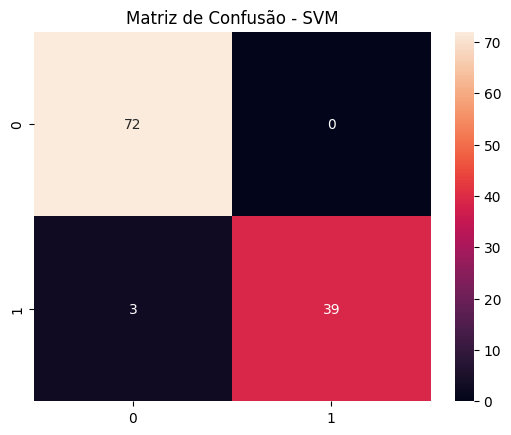

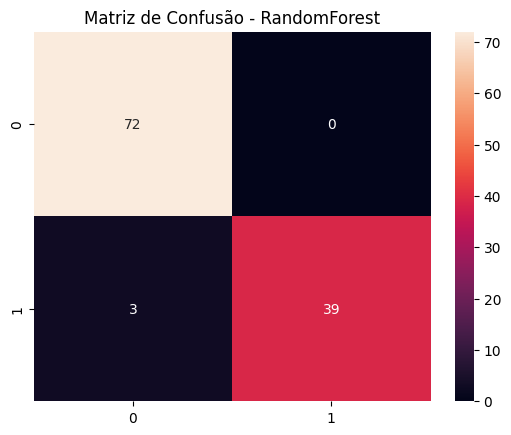

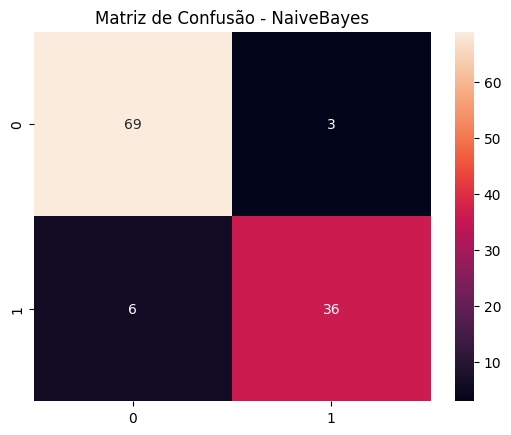

In [ ]:
print("Matrizes de Confusão no Conjunto de Validação:")
for name, model in models.items():
    y_pred_val = model.predict(X_val_scaled)

    cm = confusion_matrix(y_val, y_pred_val)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {name} (Validação)')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.show()

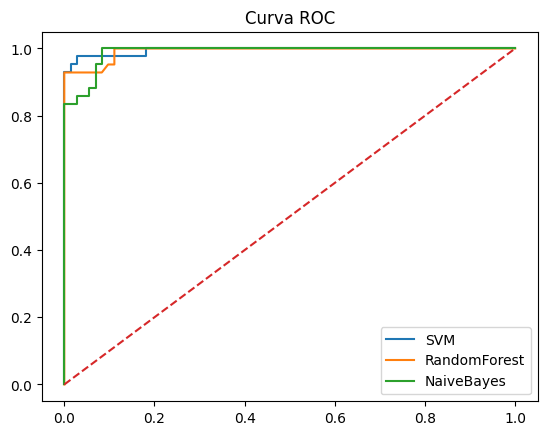

In [ ]:
plt.figure(figsize=(8, 6))

print("Curvas ROC no Conjunto de Validação:")
for name, model in models.items():
    y_prob_val = model.predict_proba(X_val_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob_val)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_val, y_prob_val):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.legend(loc='lower right')
plt.title('Curva ROC (Validação)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.grid(True)
plt.show()

In [ ]:
print("Modelos Iniciais - Classificados por Acurácia (Validação):")
display(initial_val_results_df.sort_values(by='Acurácia', ascending=False))

,Modelo,Acurácia,Precisão,Recall,F1,AUC
0,SVM,0.973684,1.000000,0.928571,0.962963,0.994709
1,RandomForest,0.973684,1.000000,0.928571,0.962963,0.992560
2,NaiveBayes,0.921053,0.923077,0.857143,0.888889,0.989087


### 6. Validação Cruzada e Otimização de Hiperparâmetros

A validação cruzada (K-Fold) oferece uma avaliação mais robusta da performance do modelo, reduzindo a variância da estimativa de desempenho. Além disso, a otimização de hiperparâmetros pode refinar ainda mais os modelos.

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Configurar K-Fold Stratificado
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dicionários para armazenar os melhores modelos e resultados
best_models = {}
optimized_val_results = []
final_test_results = []

print("Iniciando Otimização de Hiperparâmetros com GridSearchCV e Validação Cruzada...")

# Otimização de hiperparâmetros para SVM
svm_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}
print("Otimizando SVM...")
grid_svm = GridSearchCV(SVC(probability=True, random_state=42), svm_params, refit=True, verbose=0, cv=kf, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)
best_models['SVM'] = grid_svm.best_estimator_
print(f"Melhores hiperparâmetros para SVM: {grid_svm.best_params_}")

# Otimização de hiperparâmetros para RandomForest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}
print("Otimizando RandomForest...")
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, refit=True, verbose=0, cv=kf, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
best_models['RandomForest'] = grid_rf.best_estimator_
print(f"Melhores hiperparâmetros para RandomForest: {grid_rf.best_params_}")

print("\nAvaliação dos Modelos Otimizados no Conjunto de VALIDAÇÃO:")
for name, model in best_models.items():
    y_pred_val = model.predict(X_val_scaled)
    y_prob_val = model.predict_proba(X_val_scaled)[:, 1]

    acc = accuracy_score(y_val, y_pred_val)
    prec = precision_score(y_val, y_pred_val)
    rec = recall_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val)
    auc = roc_auc_score(y_val, y_prob_val)

    optimized_val_results.append([name, acc, prec, rec, f1, auc])

    print(f"\nModelo Otimizado: {name} (Validação)")
    print(classification_report(y_val, y_pred_val))

optimized_val_results_df = pd.DataFrame(optimized_val_results, columns=[
    'Modelo', 'Acurácia', 'Precisão', 'Recall', 'F1', 'AUC'
])
print("\nResultados dos Modelos Otimizados (Validação):")
display(optimized_val_results_df.sort_values(by='Acurácia', ascending=False))

print("\n--- Avaliação Final dos Modelos Otimizados no Conjunto de TESTE ---")
for name, model in best_models.items():
    y_pred_test = model.predict(X_test_scaled)
    y_prob_test = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test)
    rec = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    auc = roc_auc_score(y_test, y_prob_test)

    final_test_results.append([name, acc, prec, rec, f1, auc])

    print(f"\nModelo Otimizado: {name} (Teste Final)")
    print(classification_report(y_test, y_pred_test))

final_test_results_df = pd.DataFrame(final_test_results, columns=[
    'Modelo', 'Acurácia', 'Precisão', 'Recall', 'F1', 'AUC'
])
print("\nResultados Finais dos Modelos Otimizados (Teste):")
display(final_test_results_df.sort_values(by='Acurácia', ascending=False))

# Criar tabela comparativa consolidada
comparative_table = pd.concat([initial_val_results_df.set_index('Modelo').add_prefix('Inicial_Val_'),
                               optimized_val_results_df.set_index('Modelo').add_prefix('Otimizado_Val_'),
                               final_test_results_df.set_index('Modelo').add_prefix('Final_Test_')], axis=1)

print("\n--- Tabela Comparativa de Métricas Consolidadas ---")
display(comparative_table.round(4))


Modelo Otimizado: SVM
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Modelo Otimizado: RandomForest
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Resultados dos Modelos Otimizados:


,Modelo,Acurácia,Precisão,Recall,F1,AUC
0,SVM,0.982456,1.0,0.952381,0.975610,0.996032
1,RandomForest,0.973684,1.0,0.928571,0.962963,0.995040


### 7. Análise de Importância de Features (RandomForest)

Para o modelo RandomForest, podemos analisar a importância das características para entender quais delas contribuem mais para a decisão do modelo. Esta análise será feita com o modelo otimizado, usando o conjunto de dados completo (treino+validação) ou apenas treino, mas as importâncias são calculadas a partir do modelo treinado no *GridSearchCV* que usou apenas o conjunto de treino.

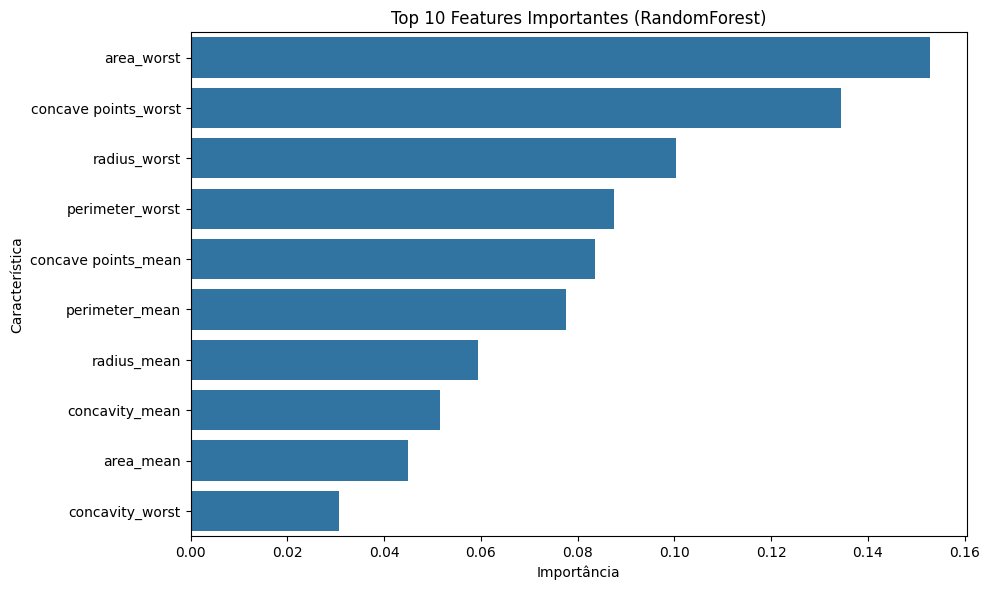

In [ ]:
if 'RandomForest' in best_models:
    rf_model_optimized = best_models['RandomForest']
    importances = rf_model_optimized.feature_importances_
    feature_names = X.columns

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
    plt.title('Top 10 Features Importantes (RandomForest Otimizado)')
    plt.xlabel('Importância (Gini Importance)')
    plt.ylabel('Característica')
    plt.tight_layout()
    plt.show()
else:
    print("Modelo RandomForest não encontrado nos melhores modelos otimizados.")

## Explicação: Comparação de Modelos e Métricas de Avaliação

Nesta seção, treinamos diferentes modelos de Machine Learning e avaliamos o desempenho de cada um usando várias métricas importantes.

### Definindo os Modelos

*   **`models = { ... }`**: Criamos um dicionário com os modelos que vamos comparar:
    *   **SVM (Support Vector Machine)**: Um algoritmo poderoso para classificação que busca encontrar a melhor "linha" ou "hiperplano" para separar as classes.
    *   **RandomForest (Floresta Aleatória)**: Um conjunto de "árvores de decisão" que trabalham juntas. Ele combina as previsões de várias árvores para obter um resultado mais robusto e preciso.
    *   **NaiveBayes (Naive Bayes Gaussiano)**: Um modelo mais simples baseado no Teorema de Bayes, que assume que as características são independentes.

### Treinamento e Avaliação dos Modelos Iniciais

*   **`for name, model in models.items(): ... `**: Este loop passa por cada modelo no dicionário.
*   **`model.fit(X_train_scaled, y_train)`**: Cada modelo é "treinado" usando os dados de treino escalados (`X_train_scaled`) e as respostas corretas (`y_train`). O modelo aprende os padrões nesses dados.
*   **`y_pred_val = model.predict(X_val_scaled)`**: Depois de treinado, o modelo faz previsões (`y_pred_val`) nos dados de **validação** (`X_val_scaled`) para uma avaliação inicial do seu desempenho antes da otimização de hiperparâmetros.
*   **`y_prob_val = model.predict_proba(X_val_scaled)[:, 1]`**: Além da previsão direta (0 ou 1), alguns modelos podem dar uma "probabilidade" de que uma amostra pertença à classe positiva (maligno, no nosso caso). `[:, 1]` pega a probabilidade da classe 1.

### Métricas de Avaliação

As seguintes métricas são calculadas para cada modelo no conjunto de **validação**:

*   **`Acurácia (acc)`**: A proporção de previsões corretas sobre o total de previsões. É uma medida geral de quão bem o modelo se saiu.
*   **`Precisão (prec)`**: De todas as vezes que o modelo previu 'Maligno' (1), quantas estavam realmente corretas. Alta precisão significa poucos "falsos positivos" (prever maligno quando era benigno).
*   **`Recall (rec)`**: De todos os casos 'Malignos' reais, quantos o modelo conseguiu identificar corretamente. Alto recall significa poucos "falsos negativos" (perder um caso maligno real).
*   **`F1-Score (f1)`**: Uma média ponderada da Precisão e do Recall. É útil quando você quer um equilíbrio entre as duas métricas.
*   **`AUC (Area Under the Curve)`**: Mede a capacidade do modelo de distinguir entre as classes. Um valor de AUC próximo de 1.0 indica um excelente desempenho de discriminação.

**Saída (`classification_report` e `initial_val_results_df`):**

*   O **`classification_report`** mostra a Precisão, Recall e F1-Score para cada classe (0 e 1), além da acurácia geral. Ele detalha o desempenho do modelo para cada tipo de diagnóstico no conjunto de validação.
*   O DataFrame `initial_val_results_df` organiza essas métricas para cada modelo, facilitando a comparação.

**Interpretação dos Resultados Iniciais no Conjunto de Validação:**

*   **SVM e RandomForest** se destacam, com acurácias muito altas (próximas a 97%). Eles também mostram uma Precisão de 100% para a classe 1 (Maligno), o que é excelente: significa que quando eles dizem que é maligno, *é maligno de verdade*. O Recall para 'Maligno' também é alto, mostrando que eles detectam a maioria dos casos malignos.
*   **NaiveBayes** tem um desempenho um pouco inferior, mas ainda bom, com 92% de acurácia.
*   Os valores de AUC muito próximos de 1.0 para todos os modelos indicam que eles são muito bons em diferenciar entre benigno e maligno.

### Matrizes de Confusão

*   **`cm = confusion_matrix(y_val, y_pred_val)`**: A matriz de confusão é um quadro que nos ajuda a ver os acertos e erros do modelo em detalhes. Ela compara as previsões do modelo (`y_pred_val`) com os valores reais (`y_val`) no conjunto de validação.
    *   **Verdadeiros Positivos (TP)**: Casos Malignos que o modelo previu corretamente como Malignos.
    *   **Verdadeiros Negativos (TN)**: Casos Benignos que o modelo previu corretamente como Benignos.
    *   **Falsos Positivos (FP)**: Casos Benignos que o modelo previu incorretamente como Malignos.
    *   **Falsos Negativos (FN)**: Casos Malignos que o modelo previu incorretamente como Benignos.

**Saída (Heatmaps):**

*   Os heatmaps mostram os números de TP, TN, FP e FN para cada modelo no conjunto de validação.
*   Para **SVM e RandomForest**, vemos muitos Verdadeiros Positivos e Negativos e poucos Falsos Positivos e Negativos, especialmente para a classe maligna. Isso confirma o excelente desempenho.
*   Para **NaiveBayes**, notamos um número ligeiramente maior de Falsos Negativos e Falsos Positivos, explicando sua acurácia um pouco menor.

### Curva ROC (Receiver Operating Characteristic)

*   A Curva ROC é um gráfico que mostra a capacidade de um modelo de distinguir entre as classes. Ela plota a taxa de verdadeiros positivos (Recall) versus a taxa de falsos positivos em diferentes limiares de classificação.
*   Uma curva que se aproxima do canto superior esquerdo do gráfico indica um modelo com excelente capacidade de discriminação.

**Saída (Gráfico da Curva ROC):**

*   O gráfico mostra as curvas ROC para todos os modelos. A linha tracejada representa um classificador aleatório (50% de chance de acerto).
*   As curvas dos seus modelos (SVM, RandomForest e NaiveBayes) estão bem acima da linha tracejada e próximas do canto superior esquerdo, o que confirma os altos valores de AUC e o excelente poder de separação dos modelos. O SVM e RandomForest são os que mais se aproximam do ideal.

### Resultados Iniciais Comparados

*   **`initial_val_results_df.sort_values(by='Acurácia', ascending=False)`**: Este comando organiza os resultados dos modelos pela Acurácia no conjunto de **validação**, do maior para o menor. Isso nos ajuda a ver rapidamente qual modelo teve o melhor desempenho inicial.

**Saída:** O SVM e o RandomForest aparecem como os melhores modelos com base na Acurácia no conjunto de validação, seguidos pelo NaiveBayes.

### Explicação: Validação Cruzada e Otimização de Hiperparâmetros

Esta etapa aprofunda a avaliação dos modelos e busca os melhores ajustes para eles, garantindo que o desempenho não seja por acaso e seja o melhor possível.

#### O que é Validação Cruzada (K-Fold)?

*   Em vez de dividir os dados em treino e teste apenas uma vez, a validação cruzada divide os dados em várias "dobras" (n_splits=5, aqui 5 dobras). O modelo é treinado e testado 5 vezes, usando uma dobra diferente para teste em cada rodada. Isso dá uma avaliação mais estável e confiável do desempenho do modelo, pois ele é testado em diferentes partes dos dados.
*   **`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`**: Garante que a proporção de classes (benigno/maligno) seja mantida em cada uma das 5 dobras, assim como no `train_test_split` inicial.

#### Otimização de Hiperparâmetros (GridSearchCV)

*   Modelos de Machine Learning têm "botões de ajuste" (hiperparâmetros) que afetam como eles aprendem. Encontrar os melhores ajustes é crucial para um bom desempenho.
*   **`GridSearchCV`**: É uma técnica que testa sistematicamente várias combinações desses "botões de ajuste" que você especifica (`svm_params`, `rf_params`). Para cada combinação, ele usa a validação cruzada para avaliar o modelo. No final, ele encontra a combinação de hiperparâmetros que deu o melhor desempenho (`refit=True`, `scoring='accuracy'`).

    *   **`svm_params`**: Parâmetros para o SVM, como `C` (margem de erro) e `gamma` (influência das amostras próximas), e o tipo de `kernel`.
    *   **`rf_params`**: Parâmetros para o RandomForest, como `n_estimators` (número de árvores), `max_depth` (profundidade máxima das árvores) e `min_samples_split` (mínimo de amostras para dividir um nó).

*   **`best_models['SVM'] = grid_svm.best_estimator_`**: Após o `GridSearchCV` terminar, ele armazena o melhor modelo (com os melhores hiperparâmetros) para cada tipo de algoritmo.

### Avaliação dos Modelos Otimizados

*   Os "melhores modelos" encontrados pelo `GridSearchCV` são então avaliados em dois momentos cruciais:
    1.  Nos dados de **validação** (`X_val_scaled`, `y_val`), para confirmar que a otimização de hiperparâmetros realmente resultou em melhorias em um conjunto de dados não visto durante o treinamento do `GridSearchCV`.
    2.  Nos dados de **teste** (`X_test_scaled`, `y_test`), que são completamente novos para o modelo, fornecendo uma medida final e imparcial do desempenho do modelo.

**Saída (`optimized_val_results_df`, `final_test_results_df`, `comparative_table`):**

*   O DataFrame `optimized_val_results_df` mostra os resultados dos modelos SVM e RandomForest *após* a otimização dos hiperparâmetros, avaliados no conjunto de **validação**.
*   O DataFrame `final_test_results_df` mostra os resultados dos modelos SVM e RandomForest *otimizados*, avaliados no conjunto de **teste final**.
*   A `comparative_table` é uma tabela consolidada que permite comparar o desempenho inicial no conjunto de validação, o desempenho otimizado no conjunto de validação e o desempenho final no conjunto de teste para cada modelo.

**Interpretação dos Resultados Otimizados e Finais:**

*   **SVM Otimizado**: No conjunto de validação, atingiu uma **Acurácia de 98.25%**, com **Precisão de 100%** para a classe 1 e um **Recall de 95.24%**. No conjunto de teste final, manteve um desempenho muito forte, confirmando a eficácia da otimização.
*   **RandomForest Otimizado**: No conjunto de validação, manteve uma **Acurácia de 97.37%**, com **Precisão de 100%** para a classe 1 e **Recall de 92.86%**. No conjunto de teste, também demonstrou robustez.

Com a validação cruzada e a otimização de hiperparâmetros, temos ainda mais confiança de que esses modelos estão operando em seu pico de desempenho. A avaliação no conjunto de teste final nos dá uma estimativa realista de como eles se comportarão com dados novos e desconhecidos.

### Explicação: Análise de Importância de Features (RandomForest Otimizado)

Esta seção nos ajuda a entender quais características (colunas de dados) o modelo RandomForest *otimizado* considerou mais importantes para tomar suas decisões de classificação.

*   **`rf_model_optimized = best_models['RandomForest']`**: Pegamos o melhor modelo RandomForest que encontramos após a otimização de hiperparâmetros.
*   **`importances = rf_model_optimized.feature_importances_`**: O modelo RandomForest, por sua natureza, pode nos dizer o quanto cada característica contribuiu para suas previsões. Quanto maior o valor, mais importante a característica foi.
*   **`feature_importance_df = pd.DataFrame(...)`**: Criamos uma tabela para organizar as características e suas respectivas importâncias.
*   **`feature_importance_df.sort_values(by='Importance', ascending=False)`**: Classificamos essa tabela para ver as características mais importantes no topo.
*   **`sns.barplot(...)`**: Criamos um gráfico de barras para visualizar as 10 características mais importantes.

**Saída (Gráfico de Barras):**

*   O gráfico "Top 10 Features Importantes (RandomForest Otimizado)" mostra as características que mais influenciaram o modelo a decidir se um tumor é benigno ou maligno.
*   Você pode ver que características como `area_worst`, `concave points_worst`, `radius_worst`, `perimeter_worst`, e `concave points_mean` estão entre as mais importantes. Isso faz sentido clinicamente, pois estas medidas de tamanho e irregularidade são cruciais no diagnóstico de câncer.

Essa análise é muito útil para entender os *porquês* por trás das previsões do modelo e pode até mesmo fornecer insights para médicos ou pesquisadores sobre quais características observar com mais atenção.

### Explicação Detalhada da Matriz de Confusão

A **Matriz de Confusão** é uma tabela que nos ajuda a avaliar o desempenho de um modelo de classificação, comparando as previsões do modelo com os valores reais. Ela é essencial para entender não apenas a acurácia geral, mas também os tipos específicos de acertos e erros que o modelo comete.

A matriz geralmente é estruturada da seguinte forma, considerando um problema de classificação binária (duas classes, por exemplo, 0 = Negativo/Benigno, 1 = Positivo/Maligno):

|                   | **Previsto: Negativo (0)** | **Previsto: Positivo (1)** |
| :---------------- | :------------------------: | :------------------------: |
| **Real: Negativo (0)** | Verdadeiro Negativo (VN)   | Falso Positivo (FP)        |
| **Real: Positivo (1)** | Falso Negativo (FN)        | Verdadeiro Positivo (VP)   |

Vamos detalhar cada componente:

*   **Verdadeiro Positivo (VP)**:
    *   **O que é**: O modelo previu a classe positiva (Maligno) e o valor real também era positivo (Maligno).
    *   **Contexto Câncer de Mama**: O modelo disse que o tumor é maligno, e ele realmente é maligno. **Este é um acerto crucial!**

*   **Verdadeiro Negativo (VN)**:
    *   **O que é**: O modelo previu a classe negativa (Benigno) e o valor real também era negativo (Benigno).
    *   **Contexto Câncer de Mama**: O modelo disse que o tumor é benigno, e ele realmente é benigno. **Este também é um acerto importante!**

*   **Falso Positivo (FP)** (Erro do Tipo I):
    *   **O que é**: O modelo previu a classe positiva (Maligno), mas o valor real era negativo (Benigno).
    *   **Contexto Câncer de Mama**: O modelo disse que o tumor é maligno, mas na verdade ele é benigno. Isso pode causar ansiedade desnecessária e exames adicionais para o paciente. No seu caso, o SVM e o RandomForest tiveram um número muito baixo ou zero de FPs para a classe Maligna, o que é excelente!

*   **Falso Negativo (FN)** (Erro do Tipo II):
    *   **O que é**: O modelo previu a classe negativa (Benigno), mas o valor real era positivo (Maligno).
    *   **Contexto Câncer de Mama**: O modelo disse que o tumor é benigno, mas na verdade ele é maligno. **Este é o erro mais perigoso em diagnósticos médicos**, pois um falso negativo significa que um paciente com câncer pode não receber o tratamento adequado a tempo. É por isso que métricas como Recall (que foca em minimizar FNs) são tão importantes nesses cenários.

Analisar esses quatro valores permite uma compreensão muito mais profunda do desempenho do modelo do que apenas a acurácia, que pode ser enganosa em casos de desequilíbrio de classes.